/usr/local/lib/python3.12/dist-packages/matplotlib/animation.py:908: UserWarning: Animation was deleted without rendering anything. This is most likely not intended. To prevent deletion, assign the Animation to a variable, e.g. `anim`, that exists until you output the Animation using `plt.show()` or `anim.save()`.
  warnings.warn(


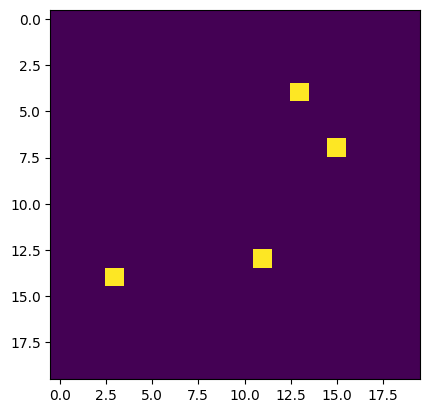

In [2]:
import numpy as np
import random
import matplotlib.pyplot as plt
import matplotlib.animation as animation

# -----------------------------
# Configuración del mundo
# -----------------------------
N = 20  # tamaño del mundo
mundo = np.zeros((N, N))

# Colocar 4 obstáculos aleatorios
obstaculos = []
while len(obstaculos) < 4:
    x, y = random.randint(0, N-1), random.randint(0, N-1)
    if (x, y) not in obstaculos:
        obstaculos.append((x, y))
        mundo[x, y] = 1  # 1 = obstáculo

# -----------------------------
# Robot
# -----------------------------
robot_x, robot_y = N//2, N//2
direccion = 0  # 0=arriba, 1=derecha, 2=abajo, 3=izquierda
movimientos = [(-1,0),(0,1),(1,0),(0,-1)]

def leer_sensores(x, y, direccion):
    sensores = []

    # Frente
    dx, dy = movimientos[direccion]
    sensores.append(mundo[(x+dx)%N, (y+dy)%N])

    # Izquierda
    dx, dy = movimientos[(direccion-1)%4]
    sensores.append(mundo[(x+dx)%N, (y+dy)%N])

    # Derecha
    dx, dy = movimientos[(direccion+1)%4]
    sensores.append(mundo[(x+dx)%N, (y+dy)%N])

    return sensores

def regla_transicion(sensores):
    frente, izquierda, derecha = sensores

    # Si hay obstáculo al frente → girar
    if frente == 1:
        if izquierda == 0:
            return "girar_izquierda"
        else:
            return "girar_derecha"

    return "avanzar"

# -----------------------------
# Animación
# -----------------------------
fig, ax = plt.subplots()
img = ax.imshow(mundo, interpolation='nearest')

def actualizar(frame):
    global robot_x, robot_y, direccion

    sensores = leer_sensores(robot_x, robot_y, direccion)
    accion = regla_transicion(sensores)

    if accion == "avanzar":
        dx, dy = movimientos[direccion]
        nuevo_x = (robot_x + dx) % N
        nuevo_y = (robot_y + dy) % N

        if mundo[nuevo_x, nuevo_y] == 0:
            robot_x, robot_y = nuevo_x, nuevo_y

    elif accion == "girar_izquierda":
        direccion = (direccion - 1) % 4

    elif accion == "girar_derecha":
        direccion = (direccion + 1) % 4

    # Crear copia para visualizar
    mundo_visual = np.copy(mundo)
    mundo_visual[robot_x, robot_y] = 2  # 2 = robot

    img.set_data(mundo_visual)
    ax.set_title(f"Paso: {frame}")
    return img,

ani = animation.FuncAnimation(fig, actualizar, frames=200, interval=300, blit=False)

plt.show()
